 # requirements

In [ ]:
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from torch.utils.data import DataLoader, Dataset, random_split
import torch
import torch.nn as nn

from sentence_transformers import SentenceTransformer
embeddings_model = SentenceTransformer('sentence-transformers/LaBSE')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6689.80it/s]


 loading the data

In [ ]:
pathfile = "../data/train.csv"
df = pd.read_csv(pathfile)
df.head()
df = pd.read_csv('../data/train.csv')
df

,uid,city,description,homeType,latitude,longitude,garageSpaces,hasSpa,yearBuilt,numOfPatioAndPorchFeatures,lotSizeSqFt,avgSchoolRating,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,priceRange
0,1748,austin,MULTIPLE OFFERS submit best & final to Agent b...,Single Family,30.380089,-97.800621,0,False,1988,0,102366.0,7.000000,17,4.0,4,650000+
1,13380,austin,"4644 Hoffman Dr, Austin, TX 78749 is a single ...",Single Family,30.199486,-97.859947,0,False,1997,0,6534.0,6.666667,16,3.0,4,350000-450000
2,4115,austin,"6804 Canal St, Austin, TX 78741 is a single fa...",Single Family,30.227398,-97.696083,0,False,1952,0,5619.0,3.333333,11,1.0,2,0-250000
3,6926,austin,Beautiful large lot with established trees. Lo...,Single Family,30.205469,-97.792351,4,False,1976,0,6416.0,4.000000,14,2.0,4,0-250000
4,14480,austin,Stunning NW Hills designer remodel by Cedar an...,Single Family,30.345106,-97.767426,2,False,1984,0,10759.0,7.000000,16,3.0,5,650000+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,8614,austin,Updated Great Hills Opportunity! Large corner ...,Single Family,30.409927,-97.763390,2,False,1982,3,15246.0,7.000000,17,3.0,3,650000+
9996,10505,austin,Adorable 3/2 in the heart of South Austin! Sit...,Single Family,30.206074,-97.779472,0,False,1970,0,6577.0,4.000000,14,2.0,3,250000-350000
9997,6942,austin,"7322 Gaines Mill Ln, Austin, TX 78745 is a sin...",Single Family,30.198936,-97.810913,0,False,1981,1,7623.0,4.000000,13,2.0,3,350000-450000
9998,1845,austin,"5213 Doe Valley Ln, Austin, TX 78759 is a sing...",Single Family,30.391880,-97.761292,0,False,1979,2,13939.2,7.000000,17,3.0,3,250000-350000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   uid                         10000 non-null  int64  
 1   city                        10000 non-null  object 
 2   description                 9999 non-null   object 
 3   homeType                    10000 non-null  object 
 4   latitude                    10000 non-null  float64
 5   longitude                   10000 non-null  float64
 6   garageSpaces                10000 non-null  int64  
 7   hasSpa                      10000 non-null  bool   
 8   yearBuilt                   10000 non-null  int64  
 9   numOfPatioAndPorchFeatures  10000 non-null  int64  
 10  lotSizeSqFt                 10000 non-null  float64
 11  avgSchoolRating             10000 non-null  float64
 12  MedianStudentsPerTeacher    10000 non-null  int64  
 13  numOfBathrooms              1000

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
uid,10000.0,7626.621900,4380.486852,1.000000,3838.750000,7603.500000,11435.750000,1.517000e+04
latitude,10000.0,30.291191,0.097075,30.085030,30.202516,30.283664,30.366375,3.051732e+01
longitude,10000.0,-97.778476,0.084543,-98.020477,-97.838594,-97.769680,-97.718313,-9.757063e+01
garageSpaces,10000.0,1.229600,1.328179,0.000000,0.000000,1.000000,2.000000,2.200000e+01
yearBuilt,10000.0,1988.570400,21.515272,1905.000000,1975.000000,1993.000000,2006.000000,2.020000e+03
numOfPatioAndPorchFeatures,10000.0,0.667200,0.986378,0.000000,0.000000,0.000000,1.000000,8.000000e+00
lotSizeSqFt,10000.0,20710.283980,448833.815153,100.000000,6534.000000,8189.000000,10890.000000,3.415452e+07
avgSchoolRating,10000.0,5.766236,1.861940,2.333333,4.000000,5.666667,7.000000,9.500000e+00
MedianStudentsPerTeacher,10000.0,14.857700,1.748473,10.000000,14.000000,15.000000,16.000000,1.900000e+01
numOfBathrooms,10000.0,2.692100,0.979206,1.000000,2.000000,3.000000,3.000000,1.000000e+01


 # feature selection
 ## objective variable
 ## value counts of the objective variable

In [ ]:
df['priceRange'].value_counts(dropna=False)

priceRange
250000-350000    2356
350000-450000    2301
450000-650000    2275
650000+          1819
0-250000         1249
Name: count, dtype: int64

 ## value counts of the objective variable

In [ ]:
df[['priceRange']].describe().T

,count,unique,top,freq
priceRange,10000,5,250000-350000,2356


 ## mapping the objective variable

In [ ]:
priceRange_map = {
    i: priceRange 
    for priceRange, i in df['priceRange'].value_counts(dropna=False).sort_values().reset_index().to_dict()['priceRange'].items()
    }
print(priceRange_map)

{'0-250000': 0, '650000+': 1, '450000-650000': 2, '350000-450000': 3, '250000-350000': 4}


%% [markdown]

In [ ]:
inverted_priceRange_map = {
    priceRange: i
    for i, priceRange in priceRange_map.items()
}
print(inverted_priceRange_map)

{0: '0-250000', 1: '650000+', 2: '450000-650000', 3: '350000-450000', 4: '250000-350000'}


 ## transforming the objective variable

In [ ]:
df['priceRange'] = df['priceRange'].map(priceRange_map)
df[['priceRange']].describe().T

,count,mean,std,min,25%,50%,75%,max
priceRange,10000.0,2.2696,1.334726,0.0,1.0,2.0,3.0,4.0


 ## value counts of the objective variable

In [ ]:
df['priceRange'].value_counts(dropna=False)

priceRange
4    2356
3    2301
2    2275
1    1819
0    1249
Name: count, dtype: int64

 ## text variable

In [ ]:
df[['description']]

,description
0,MULTIPLE OFFERS submit best & final to Agent b...
1,"4644 Hoffman Dr, Austin, TX 78749 is a single ..."
2,"6804 Canal St, Austin, TX 78741 is a single fa..."
3,Beautiful large lot with established trees. Lo...
4,Stunning NW Hills designer remodel by Cedar an...
...,...
9995,Updated Great Hills Opportunity! Large corner ...
9996,Adorable 3/2 in the heart of South Austin! Sit...
9997,"7322 Gaines Mill Ln, Austin, TX 78745 is a sin..."
9998,"5213 Doe Valley Ln, Austin, TX 78759 is a sing..."


 ## one sample

In [ ]:
df['description'][1000]

'Two secondary bedrooms. Formal dining room with a large window. Open family room with ceramic tile floor and four windows. Kitchen features a large island with built-in seating space. Library with French doors and three large windows. Private master bedroom with three large windows. Double doors lead to master bath with two sinks, a corner garden tub and an oversized closet. Covered backyard patio. Two-car garage.'

 ## creating sentence embeddings

In [ ]:
class hf_embeddings():
    def __init__(self, model):
        self.model = model

    def __call__(self, texts):
        return self.model.encode(texts)
    
embeder = hf_embeddings(embeddings_model)
samples_sentences = embeder(
        [
            "this is a test sentence",
            "this is another test sentence"
        ]
    )
print(samples_sentences.shape)
print(samples_sentences[0][:10])

(2, 768)
[ 0.01633331 -0.01122774 -0.06047796 -0.06378747  0.00241495  0.04759008
  0.01317829 -0.00777476 -0.07094021  0.01781755]


 ## creating sentence embeddings for the description variable

In [ ]:
df['description_embedings'] = list(embeder(np.array(df['description'].tolist())))
print(df['description_embedings'].shape)
print(df['description_embedings'].iloc[0][:10])
print(df.head())

(10000,)
[-0.01608405 -0.0159077  -0.0213873  -0.02958919 -0.02608652 -0.01830222
 -0.0312991  -0.00650206  0.04790219 -0.06240032]
     uid    city                                        description  \
0   1748  austin  MULTIPLE OFFERS submit best & final to Agent b...   
1  13380  austin  4644 Hoffman Dr, Austin, TX 78749 is a single ...   
2   4115  austin  6804 Canal St, Austin, TX 78741 is a single fa...   
3   6926  austin  Beautiful large lot with established trees. Lo...   
4  14480  austin  Stunning NW Hills designer remodel by Cedar an...   

        homeType   latitude  longitude  garageSpaces  hasSpa  yearBuilt  \
0  Single Family  30.380089 -97.800621             0   False       1988   
1  Single Family  30.199486 -97.859947             0   False       1997   
2  Single Family  30.227398 -97.696083             0   False       1952   
3  Single Family  30.205469 -97.792351             4   False       1976   
4  Single Family  30.345106 -97.767426             2   False      

 ## creating a dataset class

In [ ]:
class csvDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data.iloc[idx]['description_embedings']
        label = self.data.iloc[idx]['priceRange']
        return text, label

dataset = csvDataset(df)
print(f"Dataset length: {len(dataset)}")
print(f"Sample data (text, label): {dataset[0]}")

Dataset length: 10000
Sample data (text, label): (array([-1.60840470e-02, -1.59076955e-02, -2.13872995e-02, -2.95891948e-02,
       -2.60865167e-02, -1.83022246e-02, -3.12991031e-02, -6.50205556e-03,
        4.79021892e-02, -6.24003224e-02, -2.39793491e-02,  1.27550904e-02,
       -2.12459881e-02,  5.77800814e-03, -2.74090879e-02, -2.21774783e-02,
        6.19768165e-02, -1.45572145e-02, -3.24945860e-02, -1.91763453e-02,
        1.65964055e-04, -2.67877281e-02, -5.05548529e-02,  2.22949195e-03,
       -2.35181917e-02,  5.33673959e-03, -3.39978151e-02, -2.38000229e-02,
       -5.62343113e-02,  2.82813385e-02,  3.81239504e-02, -5.63255511e-03,
       -3.85388695e-02,  4.91796881e-02, -5.85236633e-03, -5.72725087e-02,
        2.03374773e-02, -4.29598317e-02,  4.79124933e-02, -6.06234558e-03,
        2.08416674e-02, -5.44034019e-02, -7.20333159e-02,  4.14875969e-02,
        2.36932859e-02, -2.44401731e-02, -4.04156931e-02,  6.47915453e-02,
       -4.71665040e-02, -4.61819656e-02, -3.244865

 ## splitting the dataset into training, validation and test sets

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
print(f"Train dataset length: {len(train_dataset)}")
print(f"Validation dataset length: {len(val_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

Train dataset length: 8000
Validation dataset length: 1000
Test dataset length: 1000


 #modeling

In [ ]:
class nn_model(nn.Module):
    def __init__(
            self,
            input_size,
            output_size
    ):
        super(nn_model, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

 ## creating a model instance

In [ ]:
input_size = df['description_embedings'].iloc[0].shape[0]
output_size = df['priceRange'].nunique()
model = nn_model(input_size, output_size)
print(model)

nn_model(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


 ## defining a loss function and an optimizer for clasification unique labels

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
num_epochs = 50

 ## training the model

In [ ]:
train_losses = []
for epoch in range(num_epochs):
    epoch_train_loss = 0
    for i, (texts, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(texts.float())
        loss = criterion(outputs, labels)
        epoch_train_loss += loss.item()

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

    train_losses.append(epoch_train_loss / len(train_loader))

Epoch [1/50], Step [10/250], Loss: 1.5892
Epoch [1/50], Step [20/250], Loss: 1.6356
Epoch [1/50], Step [30/250], Loss: 1.5393
Epoch [1/50], Step [40/250], Loss: 1.6607
Epoch [1/50], Step [50/250], Loss: 1.5732
Epoch [1/50], Step [60/250], Loss: 1.5987
Epoch [1/50], Step [70/250], Loss: 1.6681
Epoch [1/50], Step [80/250], Loss: 1.5893
Epoch [1/50], Step [90/250], Loss: 1.4763
Epoch [1/50], Step [100/250], Loss: 1.5558
Epoch [1/50], Step [110/250], Loss: 1.4951
Epoch [1/50], Step [120/250], Loss: 1.5130
Epoch [1/50], Step [130/250], Loss: 1.5173
Epoch [1/50], Step [140/250], Loss: 1.4571
Epoch [1/50], Step [150/250], Loss: 1.5307
Epoch [1/50], Step [160/250], Loss: 1.4737
Epoch [1/50], Step [170/250], Loss: 1.4741
Epoch [1/50], Step [180/250], Loss: 1.4196
Epoch [1/50], Step [190/250], Loss: 1.3407
Epoch [1/50], Step [200/250], Loss: 1.5083
Epoch [1/50], Step [210/250], Loss: 1.4119
Epoch [1/50], Step [220/250], Loss: 1.4493
Epoch [1/50], Step [230/250], Loss: 1.3567
Epoch [1/50], Step [

 ## evaluating the model on the validation set

In [ ]:
val_losses = []
with torch.no_grad():
    correct = 0
    total = 0
    for epoch in range(num_epochs):
        epoch_val_loss = 0
        for texts, labels in val_loader:
            outputs = model(texts.float())
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        val_losses.append(epoch_val_loss / len(val_loader))
print(f'Validation Accuracy: {100 * correct / total:.2f}%')

Validation Accuracy: 35.70%


 ## comparing the losses of the training and validation sets

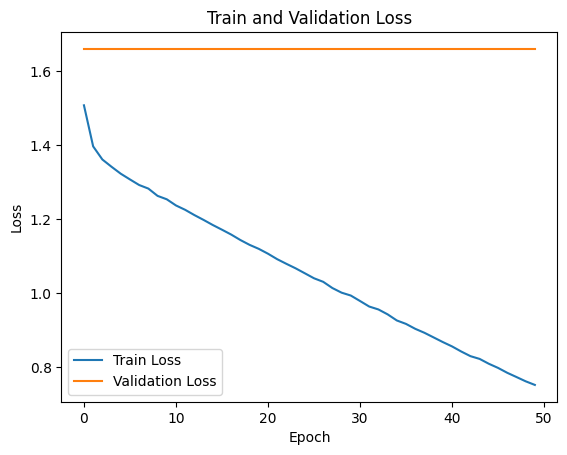

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()
plt.show()

 # saving the model

In [ ]:
timestamp = int(datetime.now().timestamp())
print(f"Saving model at timestamp: {timestamp}")
model_path = f'../data/nlpnet_model_{timestamp}.pth'
torch.save(model, model_path)

Saving model at timestamp: 1778220700


 # loading trained model class for inference

In [ ]:
original_model_path = "../data/nlpnet_model_1778220700.pth"
loaded_model = torch.load(
    original_model_path,
    weights_only=False
)
loaded_model.eval()

nn_model(
  (fc1): Linear(in_features=768, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)

 ## making predictions with the loaded model and with test data

In [ ]:
with torch.no_grad():
    correct = 0
    total = 0
    for texts, labels in test_loader:
        outputs = loaded_model(texts.float())
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy of the loaded model on the {total} test samples: {100 * correct / total:.2f}%')

Accuracy of the loaded model on the 1000 test samples: 39.00%
